# P2 sistemático y edge P0–P4: evaluación completa

**Qué es este cuaderno:** el registro reproducible de todo lo analizado entre el 2026-09-21 y el
2026-09-23 sobre P2 y sobre el edge completo. Cada número se recalcula acá, desde las bases de datos
(en **solo lectura**) y desde las velas exportadas de MT5. Nada está copiado a mano.

**Para quién:** para decidir si conviene automatizar P2, con qué modelo, y qué esperar de esa decisión.

**Cómo leerlo:** la primera sección es el resumen para decidir. El resto es la evidencia, en el orden
en que conviene leerla. La sección 12 compara tu decisión propuesta contra las alternativas.

> Texto escrito el **2026-09-23**. Si volvés a ejecutar el cuaderno con más análisis, las tablas y
> gráficos se actualizan solos. El texto de las conclusiones no, así que contrastalo con las celdas.

## 0. Resumen para decidir

| Pregunta | Respuesta corta | Dónde está la evidencia |
|---|---|---|
| ¿El edge completo (P0–P4) acierta la dirección más que el azar? | **Sí.** 42 de 61 (68.9%), p=0.013 ya corregido. Es la única prueba **fijada de antemano** que dio señal. | §3 |
| ¿Le gana a una regla simple de tendencia? | **Todavía no.** A la tendencia diaria le va ganando (17 vs 8 en los desacuerdos), pero podría ser suerte. **Contra la tendencia de 4H empata** (69% vs 70% en los mismos análisis). | §3 |
| ¿P2 cambia alguna decisión dentro del edge? | **No.** Ningún modelo invirtió una sola dirección: P2 pesa 0.075 por punto. | §5 |
| ¿El P2 calculado es mejor que tu P2 manual? | **Igual o mejor.** Cuando se contradicen, el modelo gana 6 a 2. | §6, §9 |
| ¿Qué modelo es mejor? | **F y A empatan** en aciertos menos fallos (+18). F es más preciso (71% vs 64%) pero opina menos (47% vs 72%). | §6, §8.6 |
| ¿Qué hizo mejor a F? | Cargar peso en **1H**. El precio resuelve en una mediana de 7 horas, y 1H sola ya rinde casi lo mismo que F. | §7, §8.4 |
| ¿Es sobreajuste? | **No en el sentido de "entrenado".** Hay sesgo de selección, pero sobrevive la corrección (p=0.023), es estable en el tiempo y no depende de un período bajista. | §8 |
| ¿El indicador funciona por sí solo? | **No.** En momentos al azar acierta 50%, como una moneda. El ~70% aparece solo en los momentos que elegís vos: tu ventaja está en la selección de setups y el modelo la confirma. | §8.7 |
| ¿Conviene cambiar los pesos P0–P4? | **No.** Nada mejoró fuera de muestra. | §3 |
| ¿El sistema gana plata? | **No se puede afirmar.** +0.17R por trade, pero el intervalo incluye el cero. | §3 |

**Veredicto sobre tu decisión** ("automatizar P2 con el modelo de pico en 1H sin 30M"):
**se sostiene, con dos ajustes.** Ver §12.

### Glosario mínimo

- **Edge / `calc_edge`:** tu índice direccional. Suma ponderada de P0–P4 dividida por 2. Si pasa de
  +0.26 es Bullish, si baja de −0.26 es Bearish, y en el medio es **Choppy** (no apuesta).
- **Ground truth ("la verdad"):** qué nivel tocó primero el precio después del análisis. El
  `edge_validation_price` significa que la tesis se cumplió; el `structural_invalidation`, que se rompió.
  Se mide sobre velas reales de 1H.
- **Apuesta / abstención:** un predictor "apuesta" cuando da una dirección, y "se abstiene" cuando
  dice 0 o Choppy. Las abstenciones no cuentan como acierto ni como fallo.
- **Neto:** aciertos menos fallos. Premia acertar y castiga fallar; abstenerse suma 0.
- **p (p-valor):** qué tan seguido saldría un resultado así **por pura suerte**. Menos de 0.05 se
  considera "difícil de explicar por suerte".
- **Holm:** corrección que sube la vara cuando se hacen varias preguntas a la vez.
- **IC95:** rango donde probablemente está el valor real. Si dos rangos se superponen mucho, la
  diferencia puede ser ruido.
- **Pre-registrado:** la regla de decisión se fijó **antes** de ver los resultados. Es la
  evidencia más confiable. Lo **exploratorio** se descubrió mirando los datos y hay que reconfirmarlo.

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "jupyter" else os.getcwd()
os.chdir(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import sqlite3
from collections import Counter
from dataclasses import replace
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from dotenv import load_dotenv

from cli.main import determine_market_bias
from core.math_engine import calculate_edge_score
from core.stats_tests import (binomial_test_two_sided, wilson_interval, net_score,
                              permutation_max_net_test)
from tools.p2_backtest import (MODELS, MODELS_BY_NAME, MODEL_A, MODEL_C, MODEL_D, MODEL_F,
                               ALL_TIMEFRAMES, assemble_p2_systematic_rows, calibrate_clock_offset,
                               compute_score_p2_sistematico, rescale_p2_sistematico,
                               bias_to_direction, load_ohlc_provider_from_csv, open_readonly_session)
from tools import edge_evaluation as ev

load_dotenv(os.path.join(ROOT, ".env"))
MT5 = os.path.dirname(os.getenv("P2_SYSTEMATIC_OHLC_DIR").rstrip("/"))   # .../MT5Exports
CUENTAS = {  # nombre: (DB de la cuenta, carpeta de velas en MT5Exports)
    "XAUUSD": (".data/flight_account_001_xauusd.db", "XAUUSD"),
    "BTCUSD": (".data/flight_account_002_btcusdtp.db", "BTCUSD"),
    "US100":  (".data/flight_account_003_us100.db", "USTEC"),   # en MT5 se llama USTEC
}
SEED = 20260923

# Paleta de referencia del skill de visualización (validada: 2 series + colores de estado)
INK, INK2, MUTED, GRID, AXIS, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, ORANGE, GOOD, BAD = "#2a78d6", "#eb6834", "#0ca30c", "#d03b3b"
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": AXIS, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2,
    "font.family": "sans-serif", "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "legend.frameon": False, "axes.axisbelow": True,
})
pd.set_option("display.max_colwidth", 200)
print("MT5Exports:", MT5)

MT5Exports: /mnt/c/Users/jcifu/MT5Exports


## 1. Datos y controles de calidad

Antes de medir nada hubo que corregir **cuatro problemas de datos**. Todos se encontraron durante este
trabajo y cualquiera de ellos habría contaminado los resultados:

| Problema | Qué pasaba | Cómo se corrigió |
|---|---|---|
| **Reloj de las velas corrido +3h** | MT5 entrega la hora del **servidor** (UTC+3) y el exportador la trataba como UTC. "Después de la entrada" arrancaba 3 horas antes. | Exportador corregido, y un control automático que aborta si el reloj no cuadra (§1.2). |
| **Historia insuficiente** | La ventana pedida a MT5 no cubría los fines de semana: 1D traía 794 velas, 30M 782. | Margen ×2 más un colchón de 7 días. |
| **Etiquetas de exclusión cruzadas** | 25 de 26 análisis "sin filas tácticas" sí tenían filas, con la hora vacía. | Etiquetas corregidas. No cambia ningún resultado. |
| **DB de US100 sin migrar** | Le faltaban 4 columnas nuevas y la lectura fallaba. | Se leen solo las columnas necesarias. No se tocó la DB. |

Además se validó `mark_price`, el precio que anotás al terminar un análisis. Permite incluir
**los análisis que nunca ejecutaste** y así ampliar la muestra.

In [2]:
# Carga de datos: una fila por análisis con niveles, más sus velas en el momento exacto del análisis.
def cargar(nombre):
    db, carpeta = CUENTAS[nombre]
    prov = load_ohlc_provider_from_csv(os.path.join(MT5, carpeta))
    rows, excl = assemble_p2_systematic_rows(open_readonly_session(db), prov, include_no_execution=True)
    return prov, rows, excl

DATA = {n: cargar(n) for n in CUENTAS}
resumen = []
for n, (prov, rows, excl) in DATA.items():
    resumen.append({
        "Cuenta": n,
        "Con ejecución": sum(r.timestamp_source == "tactical_audit" for r in rows),
        "Sin ejecución (mark_price)": sum(r.timestamp_source == "mark_price" for r in rows),
        "Resueltos": sum(not r.ground_truth_incompleto for r in rows),
        "Excluidos": len(excl),
        "Motivos de exclusión": ", ".join(f"{k} ({v})" for k, v in Counter(e.reason for e in excl).most_common()),
    })
pd.DataFrame(resumen).set_index("Cuenta")

,Con ejecución,Sin ejecución (mark_price),Resueltos,Excluidos,Motivos de exclusión
Cuenta,,,,,
XAUUSD,50,24,74,7,"missing_edge_validation_price_or_structural_invalidation (5), no_execution_backdated (1), zero_tactical_audit_rows (1)"
BTCUSD,11,4,15,9,"tactical_audit_rows_exist_but_entry_time_all_null (8), missing_edge_validation_price_or_structural_invalidation (1)"
US100,3,5,7,0,


### 1.1 ¿Es confiable `mark_price`?

Si `mark_price` es el precio real del momento del análisis, tiene que caer **dentro de la vela de 15
minutos** de ese momento. Lo mismo vale, con más razón, para una orden llenada: tiene que estar dentro
del rango de su vela.

In [3]:
from sqlalchemy import select
from tools.database import TacticalAudit, UnifiedDepartment

def puntos_referencia(db):
    s = open_readonly_session(db)
    fills = s.execute(select(TacticalAudit.entry_time, TacticalAudit.entry_price).where(
        TacticalAudit.order_filled == True, TacticalAudit.entry_time.isnot(None),
        TacticalAudit.entry_price > 0)).all()
    marks = s.execute(select(UnifiedDepartment.created_at, UnifiedDepartment.mark_price).where(
        UnifiedDepartment.mark_price > 0, UnifiedDepartment.is_backdated.isnot(True))).all()
    return fills, marks

def dentro_de_su_vela(prov, pts, desplazamiento_h):
    ok = tot = 0
    for t, p in pts:
        bar = prov.bar_containing("15M", t + pd.Timedelta(hours=desplazamiento_h))
        if bar:
            tot += 1; ok += bar[1] <= float(p) <= bar[0]
    return f"{ok}/{tot} ({ok/tot*100:.0f}%)" if tot else "—"

filas = []
for n, (prov, _, _) in DATA.items():
    fills, marks = puntos_referencia(CUENTAS[n][0])
    for etiqueta, pts in (("órdenes llenadas", fills), ("mark_price", marks)):
        filas.append({"Cuenta": n, "Precio": etiqueta, "n": len(pts),
                      "Reloj sin desplazar (correcto)": dentro_de_su_vela(prov, pts, 0),
                      "Reloj corrido +3h (el bug)": dentro_de_su_vela(prov, pts, 3)})
pd.DataFrame(filas).set_index(["Cuenta", "Precio"])

n Reloj sin desplazar (correcto)  \
Cuenta Precio                                                
XAUUSD órdenes llenadas  35                    26/34 (76%)   
       mark_price        70                    55/70 (79%)   
BTCUSD órdenes llenadas   4                      2/4 (50%)   
       mark_price        15                    13/15 (87%)   
US100  órdenes llenadas   1                     1/1 (100%)   
       mark_price         8                      7/8 (88%)   

                        Reloj corrido +3h (el bug)  
Cuenta Precio                                       
XAUUSD órdenes llenadas                 4/31 (13%)  
       mark_price                       7/70 (10%)  
BTCUSD órdenes llenadas                  1/4 (25%)  
       mark_price                        1/15 (7%)  
US100  órdenes llenadas                   0/1 (0%)  
       mark_price                        1/8 (12%)

**Lectura:** con el reloj correcto, la gran mayoría de las órdenes y de los `mark_price` cae dentro de
su vela, y con el reloj corrido 3 horas casi ninguno. Eso confirma dos cosas: **el reloj ahora está bien**
y **`mark_price` es el precio real del momento**. Las pocas que no cuadran son probablemente horas
anotadas a mano con unos minutos de diferencia.

### 1.2 Control automático del reloj y profundidad de la historia

`calibrate_clock_offset()` hace la prueba anterior en cada corrida y **se niega a generar resultados**
si el reloj no cuadra. Además, los modelos P2 exigen **800 velas previas** en cada temporalidad.

In [4]:
filas = []
primer = {n: min(r.timestamp_entry for r in rows) for n, (_, rows, _) in DATA.items()}
for n, (prov, _, _) in DATA.items():
    c = calibrate_clock_offset(open_readonly_session(CUENTAS[n][0]), prov)
    fila = {"Cuenta": n, "Reloj": c.describe().split(":")[0]}
    for tf in ALL_TIMEFRAMES:
        df = prov._load_tf(tf)
        k = int((df["time"] < primer[n]).sum())
        fila[tf] = f"{k}" + ("" if k >= 800 else " ✗")
    filas.append(fila)
print("Velas disponibles ANTES del primer análisis de cada cuenta (mínimo 800; ✗ = no alcanza):")
pd.DataFrame(filas).set_index("Cuenta")

Velas disponibles ANTES del primer análisis de cada cuenta (mínimo 800; ✗ = no alcanza):


,Reloj,1W,1D,12H,4H,1H,30M,15M
Cuenta,,,,,,,,
XAUUSD,OK en 15M,1466,1133,1138,1156,1166,1304,1461
BTCUSD,OK en 15M,802,1607,1614,1641,1753,1898,2244
US100,Sin calibrar,732 ✗,1135,1144,1155,1185,1296,1554


**Lectura:**
- **US100 queda "sin calibrar"** porque tiene solo 9 precios de referencia y el mínimo automático es
  10. La tabla anterior muestra igual que cuadra: 8 de 9 con el reloj correcto.
- **El broker solo tiene 732 semanas de historia de US100**, así que sus análisis quedan fuera de los
  modelos P2. Siguen dentro de la evaluación del edge (§3), que no usa la temporalidad semanal.

## 2. El mercado en el período analizado

XAUUSD desde mayo hasta la última vela exportada. **Cada marcador es uno de tus análisis**, ubicado en
el precio y la hora en que lo hiciste. La forma dice qué apostó tu edge y el color si acertó.

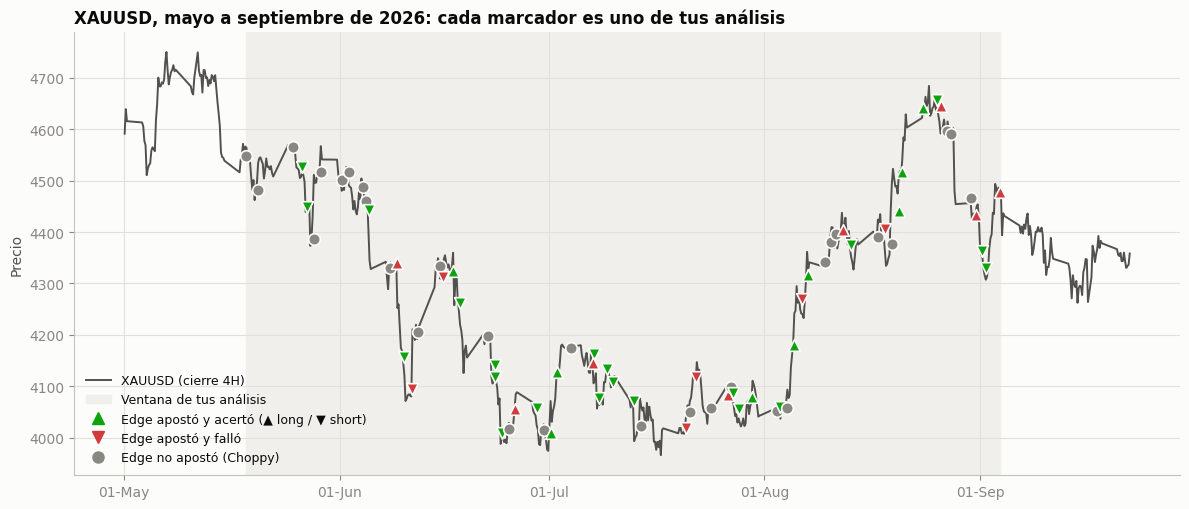

Rango: mín 3966 · máx 4750 · primer análisis 2026-05-18 · último 2026-09-03 · última vela 2026-09-22


In [5]:
prov_x, rows_x, _ = DATA["XAUUSD"]
velas = prov_x._load_tf("4H")
velas = velas[velas["time"] >= "2026-05-01"]

fig, ax = plt.subplots(figsize=(12, 5.2))
ax.plot(velas["time"], velas["close"], color=INK2, lw=1.4, label="XAUUSD (cierre 4H)")
t0 = min(r.timestamp_entry for r in rows_x); t1 = max(r.timestamp_entry for r in rows_x)
ax.axvspan(t0, t1, color="#f0efec", zorder=0, label="Ventana de tus análisis")

for r in rows_x:
    d = bias_to_direction(r.bias_predicho_original)
    ok = None if (d is None or r.ground_truth_incompleto) else d == r.ground_truth_direction
    marker = {"long": "^", "short": "v", None: "o"}[d]
    color = MUTED if ok is None else (GOOD if ok else BAD)
    ax.scatter(r.timestamp_entry, r.entry_price, marker=marker, s=70, color=color,
               edgecolor=SURF, linewidth=1.2, zorder=3)

handles = [Line2D([], [], color=INK2, lw=1.4, label="XAUUSD (cierre 4H)"),
           plt.Rectangle((0, 0), 1, 1, color="#f0efec", label="Ventana de tus análisis"),
           Line2D([], [], ls="", marker="^", ms=8, color=GOOD, label="Edge apostó y acertó (▲ long / ▼ short)"),
           Line2D([], [], ls="", marker="v", ms=8, color=BAD, label="Edge apostó y falló"),
           Line2D([], [], ls="", marker="o", ms=8, color=MUTED, label="Edge no apostó (Choppy)")]
ax.legend(handles=handles, loc="lower left", fontsize=9)
ax.set_title("XAUUSD, mayo a septiembre de 2026: cada marcador es uno de tus análisis")
ax.set_ylabel("Precio")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
plt.tight_layout(); plt.show()

print(f"Rango: mín {velas['close'].min():.0f} · máx {velas['close'].max():.0f} · "
      f"primer análisis {t0:%Y-%m-%d} · último {t1:%Y-%m-%d} · última vela {velas['time'].max():%Y-%m-%d}")

In [6]:
# ¿Fue un período direccional? Hacia dónde fue el precio en cada análisis, por mes.
todos = [r for n in ("XAUUSD", "BTCUSD") for r in DATA[n][1] if not r.ground_truth_incompleto]
por_mes = pd.crosstab(pd.Series([r.timestamp_entry.strftime("%Y-%m") for r in todos], name="Mes"),
                      pd.Series([r.ground_truth_direction for r in todos], name="El precio fue"))
por_mes.loc["Total"] = por_mes.sum()
por_mes

El precio fue,long,short
Mes,,
2026-05,4,3
2026-06,6,16
2026-07,9,10
2026-08,23,14
2026-09,1,3
Total,43,46


**Lectura:** en total el período fue **equilibrado**, 52% short y 48% long, pero con meses bien
direccionales: **junio fue bajista** (16 contra 6) y **agosto alcista** (23 contra 14). Esto importa por
dos razones. Primero, los modelos se probaron en los dos tipos de mercado, no solo en uno. Segundo, en una
versión anterior del análisis, con el bug del reloj y menos datos, parecía muy bajista, y "apostar
siempre short" parecía ganarle al edge. **Esa conclusión era falsa**: se debía al bug y a mirar solo
una parte de los datos.

## 3. ¿El edge completo acierta? (pruebas fijadas de antemano)

Estas son las únicas preguntas con reglas de decisión **fijadas antes de ver los resultados**
(plan `crea-un-plan-de-frolicking-kahn.md`). Por eso son la evidencia más confiable del cuaderno.

- **1a:** ¿acierta más que una moneda?
- **1b:** ¿le gana a "seguir la tendencia diaria" (precio contra EMA200 en 1D, calculada en el momento)?
- **1c:** ¿acierta más cuanto mayor es `|calc_edge|`?
- **2:** ¿existe un reparto de pesos P0–P4 mejor **fuera de muestra**?
- **3:** ¿se traduce en R positivo?

1a, 1b y 1c se corrigen juntas por Holm. Se usan las 3 cuentas.

In [7]:
cuentas_ev = [ev.load_account(db, os.path.join(MT5, carpeta), True) for db, carpeta in CUENTAS.values()]
filas_ev = [r for a in cuentas_ev for r in a.rows]
ejec = ev.executed_frame(filas_ev)
q1 = ev.run_question_1(filas_ev, seed=ev.DEFAULT_SEED)
q2 = ev.run_question_2(filas_ev)
q3 = ev.run_question_3(ejec, seed=ev.DEFAULT_SEED)

veredicto = [{"#": t.key, "Pregunta": t.question, "Resultado": t.statistic,
              "p": f"{t.p_value:.3f}", "p (Holm)": f"{t.p_holm:.3f}",
              "¿Señal?": "✅ sí" if t.signal else "— no concluyente"} for t in q1]
veredicto.append({"#": "2", "Pregunta": "¿Pesos mejores fuera de muestra?",
                  "Resultado": f"óptimo {q2.wf['óptimo'].accuracy*100:.1f}% vs actuales {q2.wf['actuales'].accuracy*100:.1f}% (walk-forward)",
                  "p": "—", "p (Holm)": "—", "¿Señal?": "✅ sí" if q2.signal else "— no concluyente"})
veredicto.append({"#": "3", "Pregunta": "¿R positivo?",
                  "Resultado": f"{q3.expectancy:+.2f}R por trade, IC95 [{q3.ci[0]:+.2f}, {q3.ci[1]:+.2f}], n={q3.n}",
                  "p": "—", "p (Holm)": "—", "¿Señal?": "✅ sí" if q3.signal else "— no concluyente"})
pd.DataFrame(veredicto).set_index("#")

,Pregunta,Resultado,p,p (Holm),¿Señal?
#,,,,,
1a,¿Acierta más que el azar?,42/61 = 68.9%,0.004,0.013,✅ sí
1b,¿Le gana a seguir la tendencia 1D?,discordantes: edge 17 vs tendencia 8 (de 61 pares),0.108,0.216,— no concluyente
1c,¿Acierta más con edge más fuerte?,r = +0.166 entre magnitud del edge y acierto (n=61),0.201,0.216,— no concluyente
2,¿Pesos mejores fuera de muestra?,óptimo 66.7% vs actuales 66.7% (walk-forward),—,—,— no concluyente
3,¿R positivo?,"+0.17R por trade, IC95 [-0.26, +0.62], n=37",—,—,— no concluyente


In [8]:
# Los baselines: reglas ingenuas calculadas solo con información disponible en el momento.
bets = ev.edge_bets(filas_ev)
mayoria = ev.hindsight_majority(filas_ev)
reglas = [("Edge P0–P4 (tu sistema)", lambda r: r.edge_dir),
          ("Tendencia 1D: precio vs EMA200 diaria", lambda r: r.baselines.get("B1")),
          ("Tendencia 4H: precio vs EMA200 4H", lambda r: r.baselines.get("B2")),
          ("Momentum: últimas 20 velas de 4H", lambda r: r.baselines.get("B3")),
          (f"Siempre {mayoria} (⚠️ usa retrospectiva)", lambda r: mayoria)]
filas = []
for nombre, f in reglas:
    ok, n = ev._acc_line(filas_ev, f); lo, hi = wilson_interval(ok, n)
    ok2, n2 = ev._acc_line(bets, f)
    if nombre.startswith("Edge"):
        mc = "—"
    else:
        b = sum(1 for r in bets if f(r) and r.edge_hit and f(r) != r.gt_thesis)
        c = sum(1 for r in bets if f(r) and not r.edge_hit and f(r) == r.gt_thesis)
        mc = f"edge {b} vs regla {c} · p={ev.mcnemar_exact(b, c):.2f}"
    filas.append({"Regla": nombre, "En todos los resueltos": f"{ok}/{n} = {ok/n*100:.0f}% [{lo*100:.0f}–{hi*100:.0f}]",
                  "En los análisis donde apostó tu edge": f"{ok2}/{n2} = {ok2/n2*100:.0f}%",
                  "Desacuerdos con el edge": mc})
pd.DataFrame(filas).set_index("Regla")

,En todos los resueltos,En los análisis donde apostó tu edge,Desacuerdos con el edge
Regla,,,
Edge P0–P4 (tu sistema),42/61 = 69% [56–79],42/61 = 69%,—
Tendencia 1D: precio vs EMA200 diaria,49/96 = 51% [41–61],33/61 = 54%,edge 17 vs regla 8 · p=0.11
Tendencia 4H: precio vs EMA200 4H,60/96 = 62% [53–72],43/61 = 70%,edge 7 vs regla 8 · p=1.00
Momentum: últimas 20 velas de 4H,62/96 = 65% [55–73],42/61 = 69%,edge 7 vs regla 7 · p=1.00
Siempre short (⚠️ usa retrospectiva),50/96 = 52% [42–62],33/61 = 54%,edge 19 vs regla 10 · p=0.14


In [9]:
# Pesos P0-P4 fuera de muestra (pregunta 2) y potencia (qué puede responder esta muestra)
w = pd.DataFrame([{"Pesos": k, "In-sample (inflado)": f"{q2.in_sample['óptimo in-sample' if k == 'óptimo' else k].accuracy*100:.1f}%",
                   "Walk-forward (fuera de muestra)": f"{q2.wf[k].accuracy*100:.1f}%",
                   "Dejando uno afuera (fuera de muestra)": f"{q2.loo[k].accuracy*100:.1f}%"}
                  for k in ("óptimo", "actuales", "iguales", "solo P2")]).set_index("Pesos")
print("Óptimo elegido en toda la muestra (P0/P1/P2/P3/P4):", tuple(round(x, 2) for x in q2.in_sample_best))
display(w)
pot = pd.DataFrame([{"Pregunta": p.question, "n": p.n_now, "Observado": p.observed,
                     "Brecha detectable": p.min_detectable, "n necesario": p.n_needed,
                     "Meses más": "ya alcanza" if p.months_more == 0 else (None if p.months_more is None else round(p.months_more))}
                    for p in ev.power_projection(filas_ev, ejec)]).set_index("Pregunta")
pot

Óptimo elegido en toda la muestra (P0/P1/P2/P3/P4): (0.0, 0.4, 0.05, 0.15, 0.4)


,In-sample (inflado),Walk-forward (fuera de muestra),Dejando uno afuera (fuera de muestra)
Pesos,,,
óptimo,71.6%,66.7%,70.4%
actuales,68.9%,66.7%,68.9%
iguales,66.2%,64.7%,66.2%
solo P2,64.7%,72.0%,64.7%


,n,Observado,Brecha detectable,n necesario,Meses más
Pregunta,,,,,
1a (vs azar),61,68.9% vs 50%,±17 pts,53,ya alcanza
1b (vs tendencia 1D),61,68.9% vs 54.1%,±17 pts,86,1
3 (expectancy > 0),37,+0.17R (sd 1.41),±0.65R,538,38


In [10]:
# Brecha de ejecución: ¿la tesis estructural y el trade real terminan igual?
g = ev.execution_gap(ejec)
tot = g.direction_agree + g.direction_disagree
display(pd.DataFrame({"Trade ganó": [g.confirmed_won, g.invalidated_won],
                      "Trade perdió": [g.confirmed_lost, g.invalidated_lost]},
                     index=["Tesis confirmada", "Tesis invalidada"]))
print(f"La dirección según la tesis y según el trade coincide en {g.direction_agree}/{tot} trades ejecutados "
      f"({g.direction_agree/tot*100:.0f}%); difiere en {g.direction_disagree} ({g.direction_disagree/tot*100:.0f}%).")

,Trade ganó,Trade perdió
Tesis confirmada,12,6
Tesis invalidada,4,15


La dirección según la tesis y según el trade coincide en 27/37 trades ejecutados (73%); difiere en 10 (27%).


**Lectura:**
- **1a da señal:** tu edge acierta la dirección bastante más que una moneda, y eso sobrevive a la
  corrección por hacer varias preguntas. Es el resultado más sólido de todo el trabajo.
- **1b y 1c no son concluyentes:** vas adelante de la regla de tendencia diaria, pero todavía podría ser
  suerte. Y ojo: **reglas simples de 4H** (tendencia o momentum) aciertan casi lo mismo que tu edge en
  los mismos análisis. Los desacuerdos van parejos. Es coherente con §8.4: en este horizonte, lo intradía
  predice bien.
- **Pesos P0–P4:** el reparto "óptimo" de la muestra completa **no le gana a los pesos actuales fuera
  de muestra**, aunque es muy distinto de ellos. Es la señal clásica de sobreajuste: el óptimo se ajustó
  al ruido. **Mantené los pesos actuales**, no porque sean óptimos sino porque nada demostró ser mejor.
- **Plata (R):** positivo pero incierto. Confirmarlo requiere cientos de trades más.
- La columna **"Siempre short/long"** tiene una ventaja injusta, porque sabe hacia dónde fue el período.
  Se muestra solo como referencia.

## 4. P2: qué es y cómo se calcula el P2 sistemático

Hoy **P2 lo ponés a ojo** (−2 a +2). El P2 sistemático lo calcula con reglas fijas, en varias
temporalidades:

1. **Dirección en cada temporalidad:** +1 si `precio > EMA20 > (EMA100) > EMA200`, −1 si el orden
   está invertido, y 0 en cualquier otro caso.
2. **Filtro de DI** (modelos C a F): si los DI contradicen a las EMAs, esa temporalidad vale 0.
3. **Fuerza por ADX14:** ×1 si ADX > 25, ×0.5 si está entre 20 y 25, y ×0 si es menor que 20.
4. **Suma ponderada por temporalidad**, reescalada a −2..+2 como tu P2.

Los parámetros (EMA 20/100/200, ADX 14, umbrales 20 y 25) son **valores estándar de manual**, fijados
antes de mirar los datos. **Ninguno se ajustó con los resultados.**

In [11]:
filas = []
for m in MODELS:
    pico = max(m.weights, key=m.weights.get)
    filas.append({"Modelo": m.name, "Descripción": m.label.split("— ")[-1],
                  "EMAs": "/".join(map(str, m.ema_chain)), "DI": "sí" if m.use_di else "no",
                  "Temporalidades": " ".join(m.timeframes), "Peso mayor": f"{pico} ({m.weights[pico]:.2f})",
                  "Pesos": " · ".join(f"{tf} {w:.2f}" for tf, w in m.weights.items()),
                  "Definido": "después de ver datos ⚠️" if m.name == "F" else "antes de ver datos"})
pd.DataFrame(filas).set_index("Modelo")

,Descripción,EMAs,DI,Temporalidades,Peso mayor,Pesos,Definido
Modelo,,,,,,,
A,"baseline (EMA20/200, ADX)",20/200,no,1W 1D 12H 4H 1H,1W (0.30),1W 0.30 · 1D 0.25 · 12H 0.20 · 4H 0.15 · 1H 0.10,antes de ver datos
B,+ EMA100,20/100/200,no,1W 1D 12H 4H 1H,12H (0.30),1W 0.15 · 1D 0.20 · 12H 0.30 · 4H 0.20 · 1H 0.15,antes de ver datos
C,+ EMA100 + DI,20/100/200,sí,1W 1D 12H 4H 1H,12H (0.30),1W 0.15 · 1D 0.20 · 12H 0.30 · 4H 0.20 · 1H 0.15,antes de ver datos
D,B+C + 30M,20/100/200,sí,1W 1D 12H 4H 1H 30M,1H (0.26),1W 0.08 · 1D 0.12 · 12H 0.17 · 4H 0.22 · 1H 0.26 · 30M 0.15,antes de ver datos
E,B+C+D + 15M,20/100/200,sí,1W 1D 12H 4H 1H 30M 15M,1H (0.24),1W 0.07 · 1D 0.10 · 12H 0.14 · 4H 0.19 · 1H 0.24 · 30M 0.16 · 15M 0.10,antes de ver datos
F,"pico 1H, sin 30M (D simplificado)",20/100/200,sí,1W 1D 12H 4H 1H,1H (0.31),1W 0.09 · 1D 0.14 · 12H 0.20 · 4H 0.26 · 1H 0.31,después de ver datos ⚠️


## 5. Dentro del edge, P2 no puede cambiar ninguna decisión

Antes de comparar modelos hay que saber si **sustituir P2 cambia algo**. P2 pesa `0.15 / 2 = 0.075`
por punto en `calc_edge`, y el umbral entre Choppy y direccional es ±0.26. Un cambio de P2 de un par de
puntos casi nunca alcanza para cruzarlo.

In [12]:
# Datos para toda la sección P2: XAUUSD + BTC (US100 no tiene historia semanal suficiente)
P2 = [(n, r) for n in ("XAUUSD", "BTCUSD") for r in DATA[n][1]
      if not r.ground_truth_incompleto and r.ground_truth_direction]
P2.sort(key=lambda x: x[1].timestamp_entry)
truth = np.array([1 if r.ground_truth_direction == "long" else -1 for _, r in P2])
print(f"Análisis resueltos con P2 sistemático: {len(P2)}  "
      f"(XAUUSD {sum(n == 'XAUUSD' for n, _ in P2)}, BTC {sum(n == 'BTCUSD' for n, _ in P2)})")

filas = []
for m in MODELS:
    cambia = invierte = 0; hits = apuestas = 0
    for _, r in P2:
        mr = r.model_results[m.name]
        if mr.bias_predicho and mr.bias_predicho != r.bias_predicho_original:
            cambia += 1
            if bias_to_direction(mr.bias_predicho) and bias_to_direction(r.bias_predicho_original):
                invierte += 1
        if mr.match is not None:
            apuestas += 1; hits += mr.match
    filas.append({"Modelo": m.name, "Bias distinto al tuyo": cambia, "Dirección invertida": invierte,
                  "Edge con este P2": f"{hits}/{apuestas} = {hits/apuestas*100:.1f}%"})
orig = [r.match_original for _, r in P2 if r.match_original is not None]
filas.append({"Modelo": "Tu P2", "Bias distinto al tuyo": "—", "Dirección invertida": "—",
              "Edge con este P2": f"{sum(orig)}/{len(orig)} = {sum(orig)/len(orig)*100:.1f}%"})
pd.DataFrame(filas).set_index("Modelo")

Análisis resueltos con P2 sistemático: 89  (XAUUSD 74, BTC 15)


,Bias distinto al tuyo,Dirección invertida,Edge con este P2
Modelo,,,
A,12,0,38/53 = 71.7%
B,5,0,37/56 = 66.1%
C,5,0,37/56 = 66.1%
D,4,0,37/53 = 69.8%
E,5,0,37/54 = 68.5%
F,5,0,37/52 = 71.2%
Tu P2,—,—,38/55 = 69.1%


**Lectura:** **ningún modelo invierte una sola dirección** (columna en cero), y la puntería del edge
casi no se mueve. Automatizar P2 **no cambia tus trades**: el beneficio es tiempo, consistencia y
objetividad. Si en algún momento querés que P2 pese en la decisión, eso es otra decisión (subir su
peso) y necesita su propia prueba.

## 6. P2 solo: ¿qué tan bien predice la dirección?

Se toma **solo P2** y se ignoran P0, P1, P3 y P4: positivo predice que sube, negativo que baja, 0 no opina.

- **Todos:** los 89 análisis.
- **Direccionales:** solo los análisis donde tu edge dijo Bullish o Bearish.
- **Choppy:** solo los análisis donde tu edge no apostó.

In [13]:
def pred(model):
    # +1/-1/0 por análisis, recalculado desde las velas en el momento exacto del análisis
    out = []
    for n, r in P2:
        snaps = SNAPS[(n, r.trade_id)]
        v = rescale_p2_sistematico(compute_score_p2_sistematico(snaps, model)[0])
        out.append(0 if not v else (1 if v > 0 else -1))
    return np.array(out)

SNAPS = {(n, r.trade_id): {tf: DATA[n][0].get_indicator_snapshot(tf, r.timestamp_entry) for tf in ALL_TIMEFRAMES}
         for n, r in P2}
PRED = {m.name: pred(m) for m in MODELS}
PRED["Tu P2"] = np.array([0 if not r.p2_discrecional else (1 if r.p2_discrecional > 0 else -1) for _, r in P2])
choppy = np.array([r.bias_predicho_original == "Choppy / Neutral" for _, r in P2])

def puntos(p, mask=None):
    mask = np.ones(len(p), bool) if mask is None else mask
    a = (p != 0) & mask; k = int((a & (p == truth)).sum()); n = int(a.sum())
    return k, n

filas = []
for nombre, p in PRED.items():
    fila = {"Predictor": nombre, "Neto (aciertos − fallos)": int(net_score(p, truth)[0])}
    for col, mask in (("Todos", None), ("Direccionales", ~choppy), ("Choppy", choppy)):
        k, n = puntos(p, mask); lo, hi = wilson_interval(k, n) if n else (np.nan, np.nan)
        fila[col] = f"{k}/{n} = {k/n*100:.0f}% [{lo*100:.0f}–{hi*100:.0f}]" if n else "—"
    k, n = puntos(p); fila["Opina en"] = f"{n/len(p)*100:.0f}%"
    filas.append(fila)
pd.DataFrame(filas).set_index("Predictor")

,Neto (aciertos − fallos),Todos,Direccionales,Choppy,Opina en
Predictor,,,,,
A,18,41/64 = 64% [52–75],32/42 = 76% [61–87],9/22 = 41% [23–61],72%
B,5,23/41 = 56% [41–70],19/28 = 68% [49–82],4/13 = 31% [13–58],46%
C,2,20/38 = 53% [37–68],16/25 = 64% [45–80],4/13 = 31% [13–58],43%
D,18,29/40 = 72% [57–84],24/28 = 86% [69–94],5/12 = 42% [19–68],45%
E,14,26/38 = 68% [53–81],22/26 = 85% [66–94],4/12 = 33% [14–61],43%
F,18,30/42 = 71% [56–83],25/29 = 86% [69–95],5/13 = 38% [18–64],47%
Tu P2,12,29/46 = 63% [49–75],25/32 = 78% [61–89],4/14 = 29% [12–55],52%


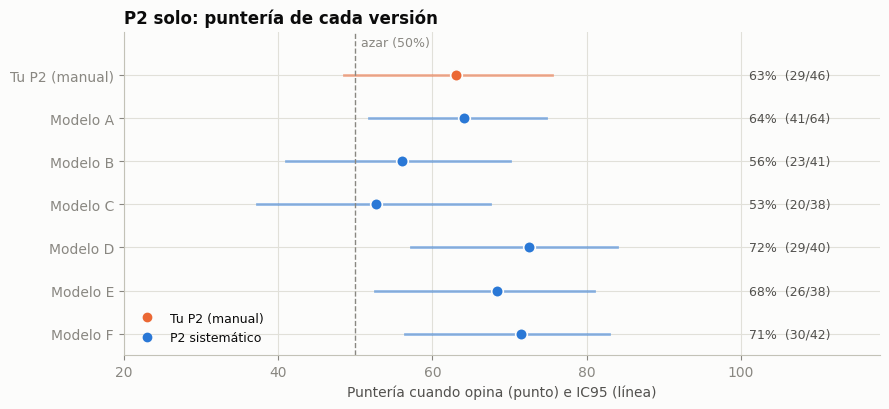

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.2))
orden = ["Tu P2"] + [m.name for m in MODELS]
for i, nombre in enumerate(orden):
    k, n = puntos(PRED[nombre]); lo, hi = wilson_interval(k, n)
    c = ORANGE if nombre == "Tu P2" else BLUE
    ax.plot([lo * 100, hi * 100], [i, i], color=c, lw=2, alpha=0.5)
    ax.scatter(k / n * 100, i, s=70, color=c, edgecolor=SURF, linewidth=1.2, zorder=3)
    ax.text(101, i, f"{k/n*100:.0f}%  ({k}/{n})", va="center", fontsize=9, color=INK2)
ax.axvline(50, color=MUTED, ls="--", lw=1)
ax.text(50.8, -0.75, "azar (50%)", color=MUTED, fontsize=9, ha="left", va="center")
ax.set_yticks(range(len(orden)), [("Tu P2 (manual)" if o == "Tu P2" else f"Modelo {o}") for o in orden])
ax.set_xlim(20, 118); ax.set_ylim(len(orden) - 0.5, -1.0); ax.set_xlabel("Puntería cuando opina (punto) e IC95 (línea)")
ax.set_title("P2 solo: puntería de cada versión")
ax.legend(handles=[Line2D([], [], ls="", marker="o", color=ORANGE, label="Tu P2 (manual)"),
                   Line2D([], [], ls="", marker="o", color=BLUE, label="P2 sistemático")],
          loc="lower left", fontsize=9)
plt.tight_layout(); plt.show()

**Lectura:**
- **A, D y F aciertan igual o más que tu P2 manual.** B y C (EMA100 + DI con pico en 12H) son peores.
- **Los intervalos se superponen:** ninguna diferencia entre modelos es concluyente por sí sola. Para
  eso son las pruebas de §8.
- **En los Choppy, todas las versiones de P2 aciertan menos que una moneda,** también la tuya. Que el
  edge no apueste en Choppy es la decisión correcta.

## 7. ¿Qué mejoró al modelo D? (experimento 2×2)

D difería de C en dos cosas a la vez: **agregar 30M** y **mover el pico de peso de 12H a 1H**. Se
aislaron cambiando una sola cosa por vez, con las mismas reglas (EMA100 + DI) en los cuatro casos.

In [15]:
C = MODEL_C.weights
VAR = {
    "C · pico 12H · sin 30M": MODEL_C,
    "C + 30M · pico 12H": replace(MODEL_C, name="C30", timeframes=MODEL_C.timeframes + ("30M",),
                                  weights={**{k: v * 0.85 for k, v in C.items()}, "30M": 0.15}),
    "F · pico 1H · sin 30M": MODEL_F,
    "D · pico 1H · con 30M": MODEL_D,
}
PV = {k: pred(m) for k, m in VAR.items()}
val = lambda p: np.where(p == 0, 0, np.where(p == truth, 1, -1))

display(pd.DataFrame([{"Variante": k, "Aciertos": f"{puntos(p)[0]}/{puntos(p)[1]}",
                       "Puntería": f"{puntos(p)[0]/puntos(p)[1]*100:.1f}%",
                       "Neto": int(net_score(p, truth)[0])} for k, p in PV.items()]).set_index("Variante"))

def comparar(a, b):
    d = val(PV[b]) - val(PV[a]); up, dn = int((d > 0).sum()), int((d < 0).sum())
    return up, dn, binomial_test_two_sided(min(up, dn), up + dn) if up + dn else 1.0

filas = []
for que, a, b in (("Mover el pico a 1H (sin 30M)", "C · pico 12H · sin 30M", "F · pico 1H · sin 30M"),
                  ("Agregar 30M (con pico en 1H)", "F · pico 1H · sin 30M", "D · pico 1H · con 30M"),
                  ("Agregar 30M (con pico en 12H)", "C · pico 12H · sin 30M", "C + 30M · pico 12H")):
    up, dn, p = comparar(a, b)
    filas.append({"Cambio": que, "Análisis que mejora": up, "Que empeora": dn, "p (test de signo)": round(p, 3)})
pd.DataFrame(filas).set_index("Cambio")

,Aciertos,Puntería,Neto
Variante,,,
C · pico 12H · sin 30M,20/38,52.6%,2
C + 30M · pico 12H,23/36,63.9%,10
F · pico 1H · sin 30M,30/42,71.4%,18
D · pico 1H · con 30M,29/40,72.5%,18


,Análisis que mejora,Que empeora,p (test de signo)
Cambio,,,
Mover el pico a 1H (sin 30M),22,6,0.004
Agregar 30M (con pico en 1H),1,1,1.000
Agregar 30M (con pico en 12H),11,3,0.057


**Lectura:** **lo que mejora es mover el peso a 1H**; agregar 30M no suma nada cuando el pico ya está
en 1H. Por eso **F** (D sin 30M) rinde igual que D con una temporalidad menos. La mejora no viene de
predecir distinto (donde C y F opinan a la vez, coinciden siempre) sino de **cuándo opina**: F se calla
en análisis donde C fallaba y opina en otros donde acierta.

## 8. ¿Es sobreajuste? Seis pruebas

La sospecha es razonable: un 71% de acierto obtenido **eligiendo el mejor modelo después de mirar los
datos** puede ser suerte. Primero hay que separar dos riesgos distintos:

| Riesgo | ¿Aplica? | Por qué |
|---|---|---|
| **Entrenamiento:** parámetros ajustados para calzar con los resultados | **No** | EMAs, ADX, umbrales y reescalado son estándar y se fijaron antes. Los pesos de A a E se definieron antes de correr los modelos. Nada se optimizó contra los resultados. |
| **Selección:** quedarse con el mejor de varios intentos | **Sí** | F se definió **después** de ver la ablación. Elegir el mejor de 7 variantes infla su resultado. |
| **Look-ahead:** usar datos posteriores al análisis | **No** | Las velas se filtran estrictamente antes del ancla (con tests), y el reloj está calibrado (§1). |

Las pruebas siguientes atacan el riesgo que sí aplica.

### 8.1 Permutación con la selección incluida

Se mezclan al azar los resultados reales 10.000 veces y, en cada mezcla, se toma **el mejor de las 7
variantes**. Si el mejor real no supera claramente al "mejor por suerte", el hallazgo no vale. Mezclar
también conserva la proporción long/short, así que esta prueba **no premia** un sesgo del período.

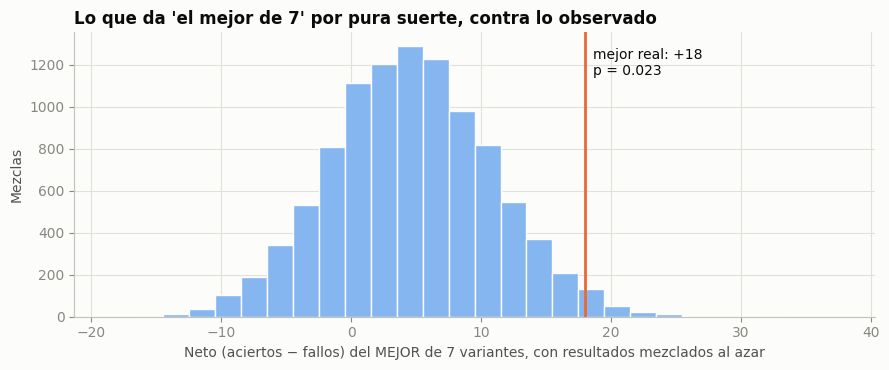

Por suerte, el mejor de 7 da en promedio +4.2; el 95% de las veces no pasa de +14.
Neto real por variante: {'A': 18, 'B': 5, 'C': 2, 'D': 18, 'E': 14, 'F': 18, 'C + 30M · pico 12H': 10}


In [16]:
nombres7 = ["A", "B", "C", "D", "E", "F", "C + 30M · pico 12H"]
M7 = np.vstack([PRED[k] if k in PRED else PV[k] for k in nombres7])
obs, p_perm, nula = permutation_max_net_test(M7, truth, n_perm=10_000, seed=SEED)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(nula, bins=np.arange(nula.min() - 0.5, nula.max() + 1.5, 2), color="#86b6ef", edgecolor=SURF)
ax.axvline(obs, color=ORANGE, lw=2)
ax.text(obs + 0.6, ax.get_ylim()[1] * 0.85, f"mejor real: +{obs}\np = {p_perm:.3f}", color=INK, fontsize=10)
ax.set_xlabel("Neto (aciertos − fallos) del MEJOR de 7 variantes, con resultados mezclados al azar")
ax.set_ylabel("Mezclas")
ax.set_title("Lo que da 'el mejor de 7' por pura suerte, contra lo observado")
plt.tight_layout(); plt.show()
print(f"Por suerte, el mejor de 7 da en promedio {nula.mean():+.1f}; el 95% de las veces no pasa de {np.quantile(nula, .95):+.0f}.")
print("Neto real por variante:", {k: int(net_score(v, truth)[0]) for k, v in zip(nombres7, M7)})

**Lectura:** aun sabiendo que se eligió al mejor de 7, **un resultado así sale por suerte solo en ~2
de cada 100 mezclas**. Y el mejor neto no es solo de F: **A, D y F lo comparten**. La señal está en el
P2 sistemático en general, no en un ajuste fino de F. Ojo: esa señal existe **en tus momentos de análisis**;
§8.7 muestra que en momentos al azar desaparece.

### 8.2 Estabilidad en el tiempo: primera mitad contra segunda mitad

In [17]:
h = len(P2) // 2
filas = []
for etiqueta, sl in (("1ª mitad", slice(0, h)), ("2ª mitad", slice(h, len(P2)))):
    d0, d1 = P2[sl][0][1].timestamp_entry, P2[sl][-1][1].timestamp_entry
    fila = {"Tramo": f"{etiqueta} ({d0:%d-%b} a {d1:%d-%b})"}
    for k in ("F", "A", "C", "Tu P2"):
        p = PRED[k][sl]; t = truth[sl]; a = p != 0
        fila[k] = f"{int((a & (p == t)).sum())}/{int(a.sum())} · neto {int(net_score(p, t)[0]):+d}"
    filas.append(fila)
pd.DataFrame(filas).set_index("Tramo")

,F,A,C,Tu P2
Tramo,,,,
1ª mitad (18-May a 26-Jul),14/20 · neto +8,17/28 · neto +6,12/20 · neto +4,14/24 · neto +4
2ª mitad (27-Jul a 03-Sep),16/22 · neto +10,24/36 · neto +12,8/18 · neto -2,15/22 · neto +8


### 8.3 Por activo

In [18]:
filas = []
for activo in ("XAUUSD", "BTCUSD"):
    m = np.array([n == activo for n, _ in P2])
    fila = {"Activo": activo, "Análisis": int(m.sum())}
    for k in ("F", "A", "C", "Tu P2"):
        p = PRED[k][m]; t = truth[m]; a = p != 0
        fila[k] = f"{int((a & (p == t)).sum())}/{int(a.sum())} · neto {int(net_score(p, t)[0]):+d}"
    filas.append(fila)
pd.DataFrame(filas).set_index("Activo")

,Análisis,F,A,C,Tu P2
Activo,,,,,
XAUUSD,74,24/34 · neto +14,30/50 · neto +10,16/33 · neto -1,24/39 · neto +9
BTCUSD,15,6/8 · neto +4,11/14 · neto +8,4/5 · neto +3,5/7 · neto +3


**Lectura de 8.2 y 8.3:** F tiene neto positivo en **las dos mitades del período**. La primera incluye el
junio bajista y la segunda el agosto alcista, así que rinde en los dos tipos de mercado. También da positivo
en XAUUSD. BTC
tiene muy pocos análisis para decir algo. Un hallazgo por casualidad suele aparecer en un tramo y
desaparecer en el otro; este no.

### 8.4 Robustez: ¿el resultado depende de un punto exacto?

Se pasa **de a poco** de los pesos de C (a=0) a los de F (a=1), y más allá. Si F fuera un golpe de suerte,
el resultado saltaría justo en a=1. Si es una tendencia real, crecería de forma gradual.

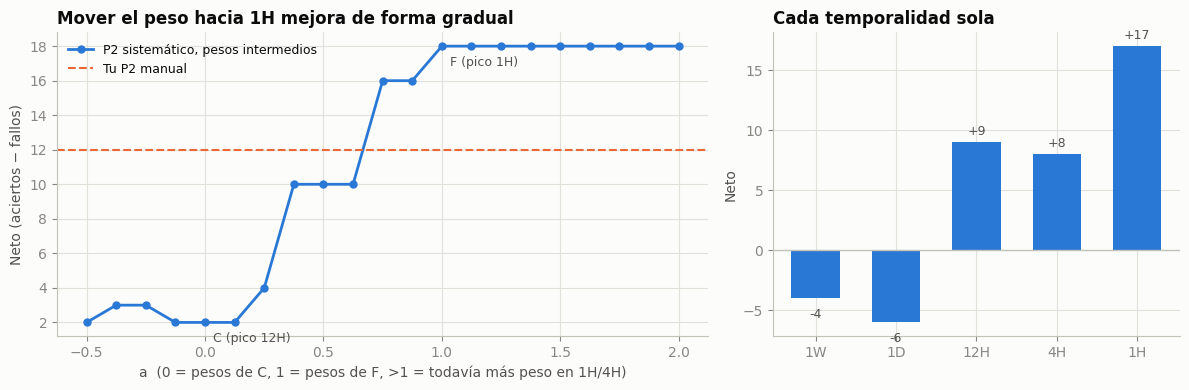

In [19]:
F_w = MODEL_F.weights
alphas = np.round(np.arange(-0.5, 2.01, 0.125), 3)
curva = []
for a in alphas:
    w = {tf: (1 - a) * C[tf] + a * F_w[tf] for tf in MODEL_C.timeframes}
    if min(w.values()) < 0:
        continue
    p = pred(replace(MODEL_C, name=f"a{a}", weights=w))
    curva.append((a, int(net_score(p, truth)[0])))
solo = {tf: int(net_score(pred(replace(MODEL_C, name=tf, timeframes=(tf,), weights={tf: 1.0})), truth)[0])
        for tf in MODEL_C.timeframes}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1.6, 1]})
xs, ys = zip(*curva)
ax1.plot(xs, ys, color=BLUE, marker="o", ms=5, label="P2 sistemático, pesos intermedios")
ax1.axhline(int(net_score(PRED["Tu P2"], truth)[0]), color=ORANGE, ls="--", lw=1.5, label="Tu P2 manual")
for a, etiqueta in ((0, "C (pico 12H)"), (1, "F (pico 1H)")):
    y = dict(curva)[a]; ax1.annotate(etiqueta, (a, y), xytext=(6, -14), textcoords="offset points", fontsize=9, color=INK2)
ax1.set_xlabel("a  (0 = pesos de C, 1 = pesos de F, >1 = todavía más peso en 1H/4H)")
ax1.set_ylabel("Neto (aciertos − fallos)"); ax1.legend(fontsize=9, loc="upper left")
ax1.set_title("Mover el peso hacia 1H mejora de forma gradual")
ax2.bar(list(solo), list(solo.values()), color=BLUE, width=0.6)
ax2.axhline(0, color=AXIS, lw=1)
for i, (tf, v) in enumerate(solo.items()):
    ax2.text(i, v + (0.6 if v >= 0 else -1.6), f"{v:+d}", ha="center", fontsize=9, color=INK2)
ax2.set_title("Cada temporalidad sola"); ax2.set_ylabel("Neto")
plt.tight_layout(); plt.show()

In [20]:
# ¿Por qué 1H? Cuánto tarda el precio en tocar uno de los dos niveles
horas = []
for n, r in P2:
    up, lo = sorted([r.edge_validation_price, r.structural_invalidation], reverse=True)
    for i, b in enumerate(DATA[n][0].get_forward_path(r.timestamp_entry, 2160)):
        if b.high >= up or b.low <= lo:
            horas.append(i + 1); break
q = np.percentile(horas, [50, 75, 90])
print(f"Horas hasta que el precio toca un nivel: mediana {q[0]:.0f} · 75% {q[1]:.0f} · 90% {q[2]:.0f}")

Horas hasta que el precio toca un nivel: mediana 7 · 75% 18 · 90% 34


**Lectura:**
- **La curva sube de forma gradual** a medida que el peso pasa a 1H y después se estabiliza. No es un
  pico casual en un punto exacto: es una tendencia con meseta, señal de algo estructural.
- **La explicación es el horizonte.** Tus tesis se resuelven en una **mediana de 7 horas**, así que la
  tendencia de 1H es la que mejor describe lo que va a pasar en ese plazo. La semanal y la diaria miran
  un horizonte mucho más largo y, solas, aciertan menos que una moneda.
- **Implicancia:** que 1H importe más **depende de cómo se mide el acierto** (primer toque de niveles
  cercanos). Si algún día medís a otro horizonte, esto habría que revisarlo.

### 8.5 ¿Acierta solo porque el período fue bajista?

In [21]:
f = PRED["F"]; a = f != 0
print(f"F dijo short {int((f < 0).sum())} veces y long {int((f > 0).sum())} veces.")
print(f"Cuando dijo long acertó {int(((f > 0) & (truth > 0)).sum())}/{int((f > 0).sum())}; "
      f"cuando dijo short, {int(((f < 0) & (truth < 0)).sum())}/{int((f < 0).sum())}.")
print(f"En esos mismos {int(a.sum())} análisis, 'siempre short' habría acertado {int((truth[a] < 0).sum())}/{int(a.sum())}.")

F dijo short 21 veces y long 21 veces.
Cuando dijo long acertó 15/21; cuando dijo short, 15/21.
En esos mismos 42 análisis, 'siempre short' habría acertado 21/42.


**Lectura:** F reparte sus apuestas mitad y mitad, y acierta igual en las dos direcciones. En los mismos
análisis, "siempre short" acertaría 50%. **No hay sesgo bajista detrás del resultado.**

### 8.6 F contra A: ¿F es realmente mejor que el modelo original?

In [22]:
d = val(PRED["F"]) - val(PRED["A"]); up, dn = int((d > 0).sum()), int((d < 0).sum())
ambos = (PRED["F"] != 0) & (PRED["A"] != 0)
filas = []
for k in ("A", "F"):
    kk, nn = puntos(PRED[k]); lo, hi = wilson_interval(kk, nn)
    filas.append({"Modelo": k, "Definido": "antes de ver datos" if k == "A" else "después de ver datos",
                  "Opina en": f"{nn}/{len(P2)} ({nn/len(P2)*100:.0f}%)",
                  "Precisión": f"{kk}/{nn} = {kk/nn*100:.1f}%  [{lo*100:.0f}–{hi*100:.0f}]",
                  "Neto": int(net_score(PRED[k], truth)[0]),
                  "Indicadores": "EMA20/200 + ADX" if k == "A" else "EMA20/100/200 + ADX + DI"})
display(pd.DataFrame(filas).set_index("Modelo"))
print(f"F mejora a A en {up} análisis y empeora en {dn} (test de signo p = {binomial_test_two_sided(min(up, dn), up + dn):.2f}).")
print(f"Donde los dos opinan ({int(ambos.sum())}), coinciden en la dirección {int((PRED['F'][ambos] == PRED['A'][ambos]).sum())} veces.")

,Definido,Opina en,Precisión,Neto,Indicadores
Modelo,,,,,
A,antes de ver datos,64/89 (72%),41/64 = 64.1% [52–75],18,EMA20/200 + ADX
F,después de ver datos,42/89 (47%),30/42 = 71.4% [56–83],18,EMA20/100/200 + ADX + DI


F mejora a A en 17 análisis y empeora en 17 (test de signo p = 1.00).
Donde los dos opinan (36), coinciden en la dirección 36 veces.


**Lectura (la más importante de esta sección):** **F no le gana a A.** Mejora en tantos análisis como
empeora, y cuando los dos opinan dicen exactamente lo mismo. F es **A pero más selectivo**: opina menos
y, cuando opina, acierta más. Ninguno domina al otro:

- **A:** opina en 3 de cada 4 análisis, usa menos indicadores y **no tiene sesgo de selección**.
- **F:** opina en la mitad de los análisis, con más precisión, pero se eligió mirando los datos.

### 8.7 ¿El indicador funciona por sí solo? F en momentos al azar

Hasta acá, F se midió solo en los momentos que **vos** elegiste para analizar y con **tus** niveles. Eso no
dice si el indicador predice algo por sí mismo. Para saberlo, se aplica F en 400 momentos al azar del mismo
período (XAUUSD), con niveles simétricos a la distancia típica de los tuyos, y se mide igual: qué nivel toca
primero el precio.

Si F tuviera poder predictivo propio, debería acertar parecido en los dos casos.

Banda simétrica: ±40.0 pts (mediana de tus distancias). Momentos al azar resueltos: 399 (subió 194, bajó 205).


,Aciertos,IC95,Opina en,p vs azar (50%)
Dónde se aplica,,,,
F en TUS momentos (XAUUSD),24/34 = 71%,[54–83],46%,0.024
F en momentos AL AZAR,104/206 = 50%,[44–57],52%,0.944
Solo 1H en momentos AL AZAR,69/144 = 48%,[40–56],36%,0.677


Diferencia F en tus momentos vs al azar: 20 pts · p = 0.029 (dos proporciones, dos colas)


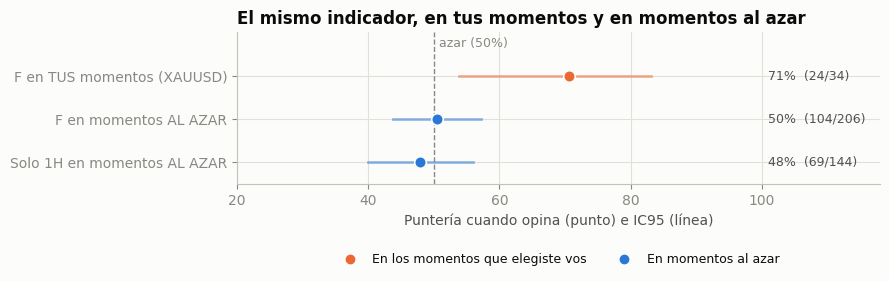

In [23]:
from core.p2_ground_truth import first_touch_direction, infer_thesis_direction
import math

prov_x = DATA["XAUUSD"][0]
xau = [r for n, r in P2 if n == "XAUUSD"]
dv = np.array([abs(r.edge_validation_price - r.entry_price) for r in xau])
di = np.array([abs(r.structural_invalidation - r.entry_price) for r in xau])
banda = float(np.median((dv + di) / 2))

h1 = prov_x._load_tf("1H")
t0, t1 = min(r.timestamp_entry for r in xau), max(r.timestamp_entry for r in xau)
cand = h1[(h1["time"] >= t0) & (h1["time"] <= t1)]
rng = np.random.default_rng(SEED)
elegidos = rng.choice(len(cand), size=min(400, len(cand)), replace=False)
anclas = sorted(cand["time"].iloc[elegidos] + pd.Timedelta(minutes=30))   # a mitad de vela, como un análisis real
solo1h = replace(MODEL_C, name="1H", timeframes=("1H",), weights={"1H": 1.0})

azar = {"F": [], "Solo 1H": []}
for a in anclas:
    a = a.to_pydatetime()
    ep = float(h1.loc[h1["time"] < a, "close"].iloc[-1])
    g, inc = first_touch_direction("long", prov_x.get_forward_path(a, 2160), ep, ep + banda, ep - banda)
    if inc or not g:
        continue
    real = 1 if g == "long" else -1
    for nombre, m in (("F", MODEL_F), ("Solo 1H", solo1h)):
        sn = {tf: prov_x.get_indicator_snapshot(tf, a) for tf in m.timeframes}
        v = rescale_p2_sistematico(compute_score_p2_sistematico(sn, m)[0])
        azar[nombre].append((0 if not v else (1 if v > 0 else -1), real))

en_xau = np.array([n == "XAUUSD" for n, _ in P2])
k_h, n_h = puntos(PRED["F"], en_xau)
resueltos = len(azar["F"])
print(f"Banda simétrica: ±{banda:.1f} pts (mediana de tus distancias). Momentos al azar resueltos: {resueltos} "
      f"(subió {sum(g > 0 for _, g in azar['F'])}, bajó {sum(g < 0 for _, g in azar['F'])}).")

filas, puntos_graf = [], []
for etiqueta, k, n, cobertura in (
        ("F en TUS momentos (XAUUSD)", k_h, n_h, n_h / int(en_xau.sum())),
        *[(f"{nom} en momentos AL AZAR", sum(p == g for p, g in v if p), sum(1 for p, _ in v if p),
           sum(1 for p, _ in v if p) / len(v)) for nom, v in azar.items()]):
    lo, hi = wilson_interval(k, n)
    filas.append({"Dónde se aplica": etiqueta, "Aciertos": f"{k}/{n} = {k/n*100:.0f}%",
                  "IC95": f"[{lo*100:.0f}–{hi*100:.0f}]", "Opina en": f"{cobertura*100:.0f}%",
                  "p vs azar (50%)": f"{binomial_test_two_sided(k, n):.3f}"})
    puntos_graf.append((etiqueta, k, n, lo, hi))
display(pd.DataFrame(filas).set_index("Dónde se aplica"))

# ¿La diferencia entre tus momentos y los momentos al azar es real? (dos proporciones, aproximación normal)
k_a = sum(p == g for p, g in azar["F"] if p); n_a = sum(1 for p, _ in azar["F"] if p)
pool = (k_h + k_a) / (n_h + n_a)
z = (k_h / n_h - k_a / n_a) / math.sqrt(pool * (1 - pool) * (1 / n_h + 1 / n_a))
print(f"Diferencia F en tus momentos vs al azar: {100*(k_h/n_h - k_a/n_a):.0f} pts · "
      f"p = {math.erfc(abs(z) / math.sqrt(2)):.3f} (dos proporciones, dos colas)")

fig, ax = plt.subplots(figsize=(9, 3.3))
for i, (etiqueta, k, n, lo, hi) in enumerate(puntos_graf):
    c = ORANGE if "TUS" in etiqueta else BLUE
    ax.plot([lo * 100, hi * 100], [i, i], color=c, lw=2, alpha=0.5)
    ax.scatter(k / n * 100, i, s=70, color=c, edgecolor=SURF, linewidth=1.2, zorder=3)
    ax.text(101, i, f"{k/n*100:.0f}%  ({k}/{n})", va="center", fontsize=9, color=INK2)
ax.axvline(50, color=MUTED, ls="--", lw=1)
ax.text(50.8, -0.75, "azar (50%)", color=MUTED, fontsize=9, ha="left", va="center")
ax.set_yticks(range(len(puntos_graf)), [e for e, *_ in puntos_graf])
ax.set_xlim(20, 118); ax.set_ylim(len(puntos_graf) - 0.5, -1.0)
ax.set_xlabel("Puntería cuando opina (punto) e IC95 (línea)")
ax.set_title("El mismo indicador, en tus momentos y en momentos al azar")
ax.legend(handles=[Line2D([], [], ls="", marker="o", color=ORANGE, label="En los momentos que elegiste vos"),
                   Line2D([], [], ls="", marker="o", color=BLUE, label="En momentos al azar")],
          loc="upper center", bbox_to_anchor=(0.5, -0.38), ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

**Lectura (la conclusión más importante de todo el §8):** en momentos al azar **F acierta lo mismo que una
moneda**. El ~70% no es una propiedad del indicador: aparece cuando se aplica **en los momentos y con los
niveles que elegís vos**.

Esto responde por qué una combinación pública de indicadores parece funcionar acá. Aplicada de forma
mecánica, en cualquier momento, **falla como fallan las estrategias públicas**. Lo que aporta valor es tu
selección de setups, y F la confirma.

Implicancias:
- F sirve como **filtro de confirmación dentro de tus análisis**, que es exactamente el uso que plantea el
  feature. **No sirve como señal independiente** (alertas, automatización en momentos arbitrarios).
- La prueba cambia a la vez el **momento** y los **niveles**, así que no separa cuál de las dos cosas aporta más.

### 8.8 Dos controles más: geometría de los niveles y momento de la medición

- **Geometría:** el acierto es qué nivel toca primero el precio. Si uno de los dos suele estar más cerca,
  gana más seguido por pura distancia. ¿F está "cobrando" esa distancia?
- **Momento:** en los trades ejecutados, F se calculó a la hora de la **entrada**, pero en el feature se va
  a calcular a la hora del **análisis**. ¿La evaluación le dio información que en producción no va a tener?

In [24]:
d2i = {"long": 1, "short": -1}
dist_v = np.array([abs(r.edge_validation_price - r.entry_price) for _, r in P2])
dist_i = np.array([abs(r.structural_invalidation - r.entry_price) for _, r in P2])
por_distancia = float(np.mean(dist_i / (dist_v + dist_i)))   # P(tocar la validación primero) si el precio fuera al azar
confirmada = float(np.mean([r.ground_truth_direction == r.thesis_direction for _, r in P2]))
print(f"Tu validación queda a {np.median(dist_v / dist_i):.2f}× la distancia de tu invalidación (mediana).")
print(f"Tesis confirmada: esperado por pura distancia {por_distancia*100:.0f}% · real {confirmada*100:.0f}%.")

cercano = np.array([1 if ((r.edge_validation_price if dv_ < di_ else r.structural_invalidation) > r.entry_price) else -1
                    for (_, r), dv_, di_ in zip(P2, dist_v, dist_i)])
tesis = np.array([d2i[r.thesis_direction] for _, r in P2])
f = PRED["F"]
filas = []
for etiqueta, pred_, mask in (("Siempre la dirección de tu tesis", tesis, None),
                              ("Siempre hacia el nivel más cercano", cercano, None),
                              ("F (todas sus apuestas)", f, None),
                              ("F cuando apunta al nivel más cercano", f, f == cercano),
                              ("F cuando apunta al nivel más lejano", f, f == -cercano)):
    k, n = puntos(pred_, mask); lo, hi = wilson_interval(k, n)
    filas.append({"Predictor": etiqueta, "Aciertos": f"{k}/{n} = {k/n*100:.0f}%", "IC95": f"[{lo*100:.0f}–{hi*100:.0f}]"})
display(pd.DataFrame(filas).set_index("Predictor"))

# Momento: F a la hora de la entrada (como se evaluó) vs a la hora del análisis (como en el feature)
horas, a_entrada, a_analisis = [], [], []
for n, r in P2:
    if r.timestamp_source != "tactical_audit":
        continue
    con = sqlite3.connect(f"file:{CUENTAS[n][0]}?mode=ro", uri=True)
    creado, mark, retro = con.execute(
        "SELECT created_at, mark_price, is_backdated FROM unified_department WHERE id = ?", (r.trade_id,)).fetchone()
    creado = datetime.fromisoformat(creado.replace(" ", "T"))
    horas.append((r.timestamp_entry - creado).total_seconds() / 3600)
    if retro or not mark or mark <= 0:
        continue
    prov = DATA[n][0]
    tesis_a = infer_thesis_direction(mark, r.edge_validation_price, r.structural_invalidation)
    g, inc = first_touch_direction(tesis_a, prov.get_forward_path(creado, 2160), mark,
                                   r.edge_validation_price, r.structural_invalidation)
    if inc or not g:
        continue
    sn = {tf: prov.get_indicator_snapshot(tf, creado) for tf in MODEL_F.timeframes}
    v = rescale_p2_sistematico(compute_score_p2_sistematico(sn, MODEL_F)[0])
    fe = r.model_results["F"].p2_sistematico_rescaled
    a_entrada.append((0 if not fe else (1 if fe > 0 else -1), d2i[r.ground_truth_direction]))
    a_analisis.append((0 if not v else (1 if v > 0 else -1), d2i[g]))
hh = np.array(horas)
print(f"\nHoras entre el análisis y la entrada (n={len(hh)}): mediana {np.median(hh):.1f} · 75% {np.percentile(hh, 75):.1f} · "
      f"máx {hh.max():.0f} · más de 1h: {int((hh > 1).sum())}")
for etiqueta, pares in (("F a la hora de la ENTRADA (como se evaluó)", a_entrada),
                        ("F a la hora del ANÁLISIS (como en el feature)", a_analisis)):
    b = [(p, g) for p, g in pares if p]; k = sum(p == g for p, g in b); lo, hi = wilson_interval(k, len(b))
    print(f"  {etiqueta:<47} {k}/{len(b)} = {k/len(b)*100:.0f}% [{lo*100:.0f}–{hi*100:.0f}]")

Tu validación queda a 1.50× la distancia de tu invalidación (mediana).
Tesis confirmada: esperado por pura distancia 41% · real 61%.


,Aciertos,IC95
Predictor,,
Siempre la dirección de tu tesis,54/89 = 61%,[50–70]
Siempre hacia el nivel más cercano,51/89 = 57%,[47–67]
F (todas sus apuestas),30/42 = 71%,[56–83]
F cuando apunta al nivel más cercano,14/19 = 74%,[51–88]
F cuando apunta al nivel más lejano,16/23 = 70%,[49–84]



Horas entre el análisis y la entrada (n=61): mediana 0.5 · 75% 1.9 · máx 52 · más de 1h: 25
  F a la hora de la ENTRADA (como se evaluó)      19/28 = 68% [49–82]
  F a la hora del ANÁLISIS (como en el feature)   20/31 = 65% [47–79]


**Lectura:**
- **La geometría juega en contra, no a favor.** Tu validación suele estar más lejos que tu invalidación. Por
  pura distancia, la tesis se confirmaría ~41% de las veces; se confirma ~61%. Y F acierta parecido apunte al
  nivel más cercano o al más lejano: no está cobrando distancia.
- **El momento casi no importa.** Calculado a la hora del análisis, F da un par de puntos menos, dentro del
  ruido. La evaluación representa bien el uso que va a tener en el feature.

### 8.9 Veredicto sobre el sobreajuste

| Prueba | Resultado | ¿Pasa? |
|---|---|---|
| ¿Se entrenó algo con los resultados? | No: todos los parámetros son estándar y fijados antes | ✅ |
| Permutación incluyendo la selección del mejor de 7 | p ≈ 0.02 | ✅ |
| Estabilidad en el tiempo | Neto positivo en las dos mitades | ✅ |
| Robustez de la forma de los pesos | Mejora gradual con meseta, no un pico | ✅ |
| Sesgo del período | Apuestas balanceadas; "siempre short" acierta 50% | ✅ |
| Geometría de los niveles | Juega en contra: por distancia la tesis se confirmaría ~41%, y se confirma ~61% | ✅ |
| Momento de la medición | Calculado a la hora del análisis, como en el feature: un par de puntos menos | ✅ |
| ¿El indicador funciona solo, en cualquier momento? | **No:** en momentos al azar acierta 50% | ⚠️ |
| ¿F es mejor que A? | **No**, son equivalentes en neto | ⚠️ |

**Conclusión:** el resultado **no es sobreajuste y no es "demasiado bueno para ser verdad"**. Es un 71%
de precisión con un rango probable de 56% a 83%: bueno, no extraordinario. Lo que sí estaba
**sobrevendido** es que F sea "el mejor modelo": es tan bueno como el original, con otro equilibrio
entre precisión y cobertura.

Y lo más importante: **el indicador por sí solo no predice nada** (§8.7). El ~70% existe en los momentos que
vos elegís analizar; en momentos al azar es una moneda. F funciona como **filtro de confirmación de tus
setups**, no como estrategia.

## 9. Human-in-the-loop: ¿el modelo propone y vos validás?

Tres situaciones posibles para cada análisis: vos y el modelo **coinciden**, **se contradicen**, o solo
uno de los dos opina.

In [25]:
yo = PRED["Tu P2"]
filas = []
for k in ("A", "F"):
    p = PRED[k]
    cons = np.where((p == yo) & (p != 0), p, 0); kc, nc = puntos(cons)
    contra = (p != 0) & (yo != 0) & (p != yo)
    filas.append({"Modelo": k,
                  "Vos solo": f"{puntos(yo)[0]}/{puntos(yo)[1]} = {puntos(yo)[0]/puntos(yo)[1]*100:.0f}% (p={binomial_test_two_sided(*puntos(yo)):.2f})",
                  "Modelo solo": f"{puntos(p)[0]}/{puntos(p)[1]} = {puntos(p)[0]/puntos(p)[1]*100:.0f}%",
                  "Cuando coinciden": f"{kc}/{nc} = {kc/nc*100:.0f}% (p={binomial_test_two_sided(kc, nc):.3f})",
                  "Cuando se contradicen": f"gana el modelo {int((contra & (p == truth)).sum())}, ganás vos {int((contra & (yo == truth)).sum())}"})
pd.DataFrame(filas).set_index("Modelo")

,Vos solo,Modelo solo,Cuando coinciden,Cuando se contradicen
Modelo,,,,
A,29/46 = 63% (p=0.10),41/64 = 64%,18/23 = 78% (p=0.011),"gana el modelo 7, ganás vos 3"
F,29/46 = 63% (p=0.10),30/42 = 71%,20/24 = 83% (p=0.002),"gana el modelo 6, ganás vos 2"


**Lectura:**
- **Cuando vos y el modelo coinciden, aciertan entre 78% (con A) y 83% (con F),** mucho más que
  cualquiera de los dos solo. Es la señal más fuerte que apareció sobre P2.
- **Cuando se contradicen, el modelo suele tener razón.** Son pocos casos para asegurarlo, pero no hay
  evidencia de que tu corrección mejore al modelo.
- **La forma recomendada es "consenso":** el modelo propone. Si coincidís, queda ese valor. Si no
  coincidís, **P2 = 0**, en vez de imponer el tuyo.
- Todo esto es **exploratorio**: hay que reconfirmarlo con análisis nuevos (§12).

## 10. El bug de `analisis_edge()` en `custom_analysis.ipynb`

La Sección 7 de `custom_analysis.ipynb` dice que P2 acierta 47.6% y que *"P2, P3, P4 están por debajo
de 50%, restan al compuesto"*. Esa conclusión viene de un bug de `core/edge_analysis.py:analisis_edge()`:
**cuenta todo análisis Choppy como pérdida**, porque ahí la "dirección real" vale 0 y ningún signo puede
coincidir con 0.

In [26]:
import sqlite3
con = sqlite3.connect("file:.data/flight_account_001_xauusd.db?mode=ro", uri=True)
datos = con.execute('''SELECT u.market_bias, e.specific_bias_compliance, l.layer_name, l.score
    FROM unified_department u JOIN efficiency_audit e ON e.id = u.id
    JOIN analysis_layer l ON l.trade_id = u.id WHERE e.specific_bias_compliance IS NOT NULL''').fetchall()
def outcome(b, c):   # misma regla que core/edge_analysis.get_market_outcome
    return {("Bullish", "Valid"): 1, ("Bullish", "Invalid"): -1, ("Bearish", "Valid"): -1,
            ("Bearish", "Invalid"): 1}.get((b, c), 0)
sg = lambda x: (x > 0) - (x < 0)
filas = []
for p in ("P0", "P1", "P2", "P3", "P4"):
    act = [(b, c, s) for b, c, l, s in datos if l == p and s]
    w = sum(sg(s) == outcome(b, c) for b, c, s in act)
    dirc = [(b, c, s) for b, c, s in act if outcome(b, c) != 0]
    w2 = sum(sg(s) == outcome(b, c) for b, c, s in dirc)
    filas.append({"Parámetro": p, "Como lo calcula el notebook": f"{w}/{len(act)} = {w/len(act)*100:.1f}%",
                  "Sin contar Choppy como pérdida": f"{w2}/{len(dirc)} = {w2/len(dirc)*100:.1f}%",
                  "Pérdidas automáticas por Choppy": len(act) - len(dirc)})
pd.DataFrame(filas).set_index("Parámetro")

,Como lo calcula el notebook,Sin contar Choppy como pérdida,Pérdidas automáticas por Choppy
Parámetro,,,
P0,24/46 = 52.2%,24/34 = 70.6%,12
P1,27/62 = 43.5%,27/40 = 67.5%,22
P2,20/42 = 47.6%,20/26 = 76.9%,16
P3,21/47 = 44.7%,21/32 = 65.6%,15
P4,22/55 = 40.0%,22/33 = 66.7%,22


**Lectura:** corregido, **ninguna capa queda por debajo de 50%**. La conclusión de que P2, P3 y P4
"restan" no se sostiene. **El bug sigue sin corregir** en `core/edge_analysis.py`: es código de producción
y espera tu visto bueno. Está documentado en `CLAUDE.md` (sección "Auditoría de análisis de datos").

## 11. Limitaciones: lo que este análisis NO puede decir

- **Muestra chica:** 89 análisis para P2 y 61 apuestas para el edge. Diferencias de menos de ~15 puntos
  son difíciles de distinguir del ruido.
- **Un solo período** (mayo a septiembre de 2026). No sabemos cómo se comporta en otros regímenes de mercado.
- **"Acertar la dirección" no es "ganar plata".** En 10 de 37 trades ejecutados (27%), la tesis y el
  trade terminan con resultados opuestos: la tesis se cumplió pero el stop saltó antes, o al revés (§3).
- **La ventaja depende de tu selección de momentos y niveles** (§8.7). No sabemos cuál de las dos aporta más,
  porque la prueba cambia ambas a la vez.
- **La ventaja de 1H depende de la definición de acierto:** primer toque de niveles cercanos, con una
  mediana de 7 horas.
- **F y el consenso son exploratorios.** Se descubrieron mirando los datos, así que su número real
  probablemente sea algo menor.
- **US100** tiene 8 análisis y no entra en los modelos P2 por falta de historia semanal.

## 12. Decisión

**Tu propuesta:** *"automatizar P2 con el modelo de pico en 1H sin 30M (F), por ser la estrategia más
sencilla".*

| Opción | A favor | En contra |
|---|---|---|
| **1. Seguir con P2 manual** | Cero trabajo | Tu P2 solo no le gana claramente al azar; es subjetivo y te lleva tiempo |
| **2. Automatizar con A** (original) | Sin sesgo de selección · opina en 72% · menos indicadores | Precisión 64% |
| **3. Automatizar con F** (tu propuesta) | Precisión 71% · consenso con vos 83% · una temporalidad menos que D | Elegido mirando los datos · opina en 47% · más indicadores que A |
| **4. F en modo consenso, con A registrado en paralelo** | Lo mejor de F, más un control que resuelve F contra A con datos nuevos | Hay que registrar dos cálculos (automáticos, sin costo para vos) |

### Recomendación: opción 4, que es tu propuesta con dos ajustes

1. **Automatizá P2 con F, en modo consenso:** el modelo propone; si coincidís queda, y si no, P2 = 0.
   Se justifica por la precisión de F y por el 83% de acierto en consenso.
2. **Registrá también A**, en silencio. F y A son equivalentes con los datos actuales, y F se eligió
   mirando esos datos. La única forma honesta de confirmar a F es compararlo con A **en análisis nuevos**.
3. **Regla fijada desde hoy** (pre-registro): tras **40 análisis nuevos resueltos**, se comparan F y A
   con el test de signo de §8.6. Si A gana con p < 0.05, se pasa a A. En cualquier otro caso, F se queda.

Una corrección de matiz: **F no es "la estrategia más sencilla"**. Es más simple que D, pero usa más
indicadores que A, y **la temporalidad 1H sola rinde casi lo mismo** (§8.4). Si la simplicidad es tu
prioridad, "solo 1H" es el candidato a vigilar; conviene registrarlo en paralelo junto con A.

### Qué esperar de la decisión (y qué no)

- **Ganás:** tiempo en cada análisis, consistencia, y un P2 que no depende del ánimo del día.
- **No cambia tus trades:** con el peso actual, P2 no invierte ninguna decisión del edge (§5).
- **No mejora tu resultado en plata:** eso no se puede afirmar con esta muestra (§3).
- **F no sirve como señal independiente:** en momentos arbitrarios acierta 50% (§8.7). Usalo solo dentro de
  tus análisis, que es exactamente lo que hace el feature.

### El hallazgo más importante que no es sobre P2

En los mismos análisis donde apostó tu edge, **"seguir la tendencia de 4H" acierta lo mismo que el edge
completo** (70% vs 69%, desacuerdos 8 a 7). Es exploratorio y no invalida la señal de 1a: tu edge le gana
al azar. Pero hoy **no hay evidencia de que le gane a una regla simple de 4H**. Si con más datos se
confirma, tu ventaja real no estaría en el análisis direccional sino en otra parte (qué setups tomás,
dónde entrás, dónde ponés el stop). Vale la pena convertirlo en la próxima prueba pre-registrada.

### Próximos pasos

1. Corregir el bug de `analisis_edge()` y regenerar la Sección 7 de `custom_analysis.ipynb`.
2. Commitear el trabajo (hoy todo está sin commitear).
3. Integrar la propuesta automática de P2 al wizard de análisis. Es un cambio de código aparte.
4. Volver a ejecutar este cuaderno cada ~20 análisis nuevos. La regla de decisión ya está fijada.
5. Pre-registrar la comparación del edge contra la tendencia de 4H en análisis nuevos (ver arriba).

## Anexo: bitácora y archivos

| Fecha | Qué pasó | Efecto |
|---|---|---|
| 21-sep | Primer export MT5; 1D con 794 velas | Margen de ventana corregido |
| 21-sep | Decisiones aprobadas: path en 1H (tope 2.160); vela que toca ambos niveles = incompleto; Choppy = abstención | Reglas de medición fijas |
| 21-sep | Bug: se comparaba "Bullish" contra "long" y siempre daba fallo | Corregido (`bias_to_direction`) |
| 22-sep | Modelos B a E; 5M reemplazado por 15M; colchón de 7 días para intradía | — |
| 22-sep | **Bug del reloj +3h** (hora del servidor MT5) | Exportador corregido y control automático |
| 22-sep | `mark_price` validado; etiquetas de exclusión corregidas | Muestra ampliada a los análisis sin ejecución |
| 22-sep | Evaluación pre-registrada del edge; re-export de XAUUSD, BTCUSD y USTEC | 1a con señal (p=0.013) |
| 22-sep | Bug de `analisis_edge()` (Choppy como pérdida) | Documentado, **pendiente** |
| 22-sep | `CLAUDE.md` sobrescrito, restaurado desde git; sección de auditoría de notebooks | — |
| 22-sep | Ablación de D, que da origen al modelo F | — |
| 23-sep | Verificación de sobreajuste (§8) y este cuaderno | F ≈ A; sin sobreajuste |
| 23-sep | Momentos al azar, geometría y momento de medición (§8.7–8.8) | El indicador solo = moneda; la ventaja es tu selección |

| Archivo | Qué hace |
|---|---|
| `tools/p2_backtest.py` | Modelos A a F, ground truth, chequeo de reloj, reporte P2 |
| `tools/edge_evaluation.py` | Preguntas pre-registradas del edge y su reporte |
| `core/stats_tests.py` | Tests estadísticos sin scipy (binomial, McNemar, Wilson, Holm, bootstrap, permutación) |
| `core/p2_ground_truth.py` | Qué nivel tocó primero el precio |
| `windows_export/export_p2_ohlc.py` | Exportador de velas MT5, con el reloj del servidor corregido |
| `jupyter/p2_systematic_report.md`, `jupyter/edge_evaluation_report.md` | Reportes regenerables |
| `tests/test_p2_*.py`, `tests/test_edge_evaluation.py`, `tests/test_stats_tests.py` | Tests de todo lo anterior |